In [11]:
# Install libraries needed for the project in the active environment
%pip install pandas openpyxl sentence-transformers scikit-learn transformers matplotlib seaborn

     ------------------------------------ 596.4/596.4 kB 412.2 kB/s eta 0:00:00
     -------------------------------------- 11.6/11.6 MB 476.5 kB/s eta 0:00:00
     -------------------------------------- 676.7/676.7 kB 1.1 MB/s eta 0:00:00
     -------------------------------------- 771.9/771.9 kB 1.7 MB/s eta 0:00:00
     ------------------------------------ 122.0/122.0 MB 723.1 kB/s eta 0:00:00
     -------------------------------------- 278.0/278.0 kB 2.9 MB/s eta 0:00:00
     -------------------------------------- 158.6/158.6 kB 2.4 MB/s eta 0:00:00
     -------------------------------------- 355.5/355.5 kB 1.3 MB/s eta 0:00:00
     ---------------------------------------- 2.7/2.7 MB 1.3 MB/s eta 0:00:00
     -------------------------------------- 122.7/122.7 kB 1.8 MB/s eta 0:00:00
     -------------------------------------- 119.2/119.2 kB 1.8 MB/s eta 0:00:00
     ------------------------------------ 203.9/203.9 kB 824.3 kB/s eta 0:00:00
     -------------------------------------


[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1. BUSINESS UNDERSTANDING

### Latar Belakang
Subdirektorat Monitoring dan Evaluasi (MONEV) menerima ribuan tiket pertanyaan/keluhan pelanggan melalui live chat, email, dan media sosial setiap bulannya. Saat ini, belum ada analisis sentimen yang terstruktur untuk mengukur kepuasan pelanggan secara objektif. Kategori tiket yang diinput secara manual oleh agen sering kali tidak konsisten dan tidak mencerminkan sentimen riil pelanggan.

### Tujuan Bisnis
1. Mengukur tingkat kepuasan pelanggan berdasarkan analisis sentimen otomatis.
2. Mengidentifikasi kategori layanan dengan tingkat sentimen negatif tertinggi untuk prioritas perbaikan.
3. Menemukan kata kunci utama keluhan pelanggan (root cause).
4. Memberikan rekomendasi perbaikan layanan yang konkret dan terukur.

### Pertanyaan Bisnis
- Bagaimana distribusi sentimen (positif, netral, negatif) pelanggan di seluruh channel layanan?
- Kategori layanan apa yang memiliki persentase sentimen negatif tertinggi?
- Apa kata kunci yang paling sering muncul pada keluhan bersentimen negatif?

# 2. DATA UNDERSTANDING

Pada tahap ini, kita akan membaca semua file data dari berbagai channel (Live Chat, Email, dan Media Sosial), menggabungkannya, menstandardisasi kolom-kolom utama, dan menganalisis karakteristik awal data.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

def try_read_csv(file_path, separators=[';', ','], encodings=['utf-8', 'latin1', 'cp1252']):
    for sep in separators:
        for encoding in encodings:
            try:
                df = pd.read_csv(file_path, sep=sep, encoding=encoding)
                print(f"   ✅ Berhasil membaca {file_path}: sep='{sep}', encoding='{encoding}'")
                return df
            except Exception:
                continue
    return None

file_configs = {
    'Live Chat': 'Report Ticket Multichat Monev_2026-07-13_08.43.17.csv',
    'Social Media': 'Report Ticket Sosmed Monev_2026-07-13_10.39.29.csv',
    'Email': 'Report Ticket Email Monev_2026-07-13_10.38.40.csv'
}

combined_dfs = []
for channel, file_name in file_configs.items():
    if os.path.exists(file_name):
        df_temp = try_read_csv(file_name)
        if df_temp is not None:
            df_temp['channel_source'] = channel
            combined_dfs.append(df_temp)
    else:
        print(f"⚠️ File {file_name} tidak ditemukan!")

df_raw = pd.concat(combined_dfs, ignore_index=True) if combined_dfs else pd.DataFrame()
print(f"\nTotal data mentah tergabung: {len(df_raw)} baris, {len(df_raw.columns)} kolom")

# Standardisasi nama kolom penting (lowercase dan strip)
df_raw.columns = df_raw.columns.str.strip().str.lower()

# Cek kolom penting
required_cols = ['ticket number', 'customer id', 'pertanyaan', 'jawaban', 'category', 'sub category']
print("\nCek ketersediaan kolom utama:")
for col in required_cols:
    status = "Ada" if col in df_raw.columns else "TIDAK ADA"
    print(f"- {col}: {status}")

# Distribusi data per channel
if 'channel_source' in df_raw.columns:
    print("\nDistribusi data per channel:")
    print(df_raw['channel_source'].value_counts())


   ✅ Berhasil membaca Report Ticket Multichat Monev_2026-07-13_08.43.17.csv: sep=';', encoding='latin1'
   ✅ Berhasil membaca Report Ticket Sosmed Monev_2026-07-13_10.39.29.csv: sep=';', encoding='latin1'
   ✅ Berhasil membaca Report Ticket Email Monev_2026-07-13_10.38.40.csv: sep=';', encoding='latin1'

Total data mentah tergabung: 6616 baris, 27 kolom

Cek ketersediaan kolom utama:
- ticket number: Ada
- customer id: Ada
- pertanyaan: Ada
- jawaban: Ada
- category: Ada
- sub category: Ada

Distribusi data per channel:
channel_source
Live Chat       5303
Email           1026
Social Media     287
Name: count, dtype: int64


# 3. DATA PREPARATION

Pada tahap ini, kita akan:
1. Mengidentifikasi dan menghapus pesan otomatis (Auto-Reply/Greeting Bot).
2. Menghash `customer_id` untuk menjaga privasi data.
3. Membersihkan teks (Light Preprocessing) yang optimal untuk model Transformer (tanpa stemming dan stopword removal agar konteks alami kalimat tidak hilang).
4. Melakukan normalisasi slang/kata gaul.

In [13]:
import re
import hashlib

# 1. Definisi Pattern Auto-Reply terpadu
AUTO_REPLY_PATTERNS = [
    r"Selamat datang di Bravo Bea Cukai",
    r"Selamat datang di Layanan Webchat",
    r"Hello! Welcome to Tj\. Priok Customs",
    r"Silakan masukan angka sesuai dengan layanan",
    r"Silakan pilih kantor Layanan Bea Cukai",
    r"Silakan pilih Identitas / Identity",
    r"Penjaluran / Line Classification",
    r"Disclaimer: Segala chat disini merupakan jawaban",
    r"Mohon tunggu beberapa saat untuk terhubung",
    r"Karena sudah tidak ada respons lagi",
    r"We've noticed you're away",
    r"Terima kasih telah menggunakan layanan webchat kami",
    r"Untuk partisipasi peningkatan kualitas layanan",
    r"surveiwebchatpriok",
    r"s\.kemenkeu\.go\.id/survei",
    r"Halo Sdr/i",
    r"Halo,\s*[a-zA-Z0-9_]+",
    r"Silakan tinggalkan pertanyaan Anda",
    r"Petugas kami akan segera merespon",
    r"Terkait barang kiriman silakan cek",
    r"https://old\.beacukai\.go\.id/web-apps/barangkiriman",
    r"jam layanan kami.*?08\.00.*?17\.00",
    r"Harap berhati-hati atas Penipuan",
    r"Semua pembayaran Bea Masuk dan Pajak hanya melalui rekening",
    r"#beacukaimakinbaik",
    r"Dalam rangka meningkatkan kepuasan",
    r"Survey Kepuasan Pelanggan",
    r"Contact Centre Bravo Bea Cukai",
    r"Email ini telah diterima secara otomatis",
    r"Auto reply",
    r"Out of office",
    r"Balasan otomatis"
]

AUTO_REPLY_REGEX = re.compile("|".join(AUTO_REPLY_PATTERNS), re.IGNORECASE)

def is_auto_reply(text):
    if pd.isna(text) or str(text).strip() == "":
        return True
    return bool(AUTO_REPLY_REGEX.search(str(text)))

# Filter data dari auto-reply
df_prepared = df_raw.copy()
df_prepared['is_auto'] = df_prepared['pertanyaan'].apply(is_auto_reply)
df_clean = df_prepared[df_prepared['is_auto'] == False].copy()

print(f"Data sebelum filter auto-reply: {len(df_prepared)} baris")
print(f"Data setelah filter auto-reply: {len(df_clean)} baris (dibuang: {len(df_prepared) - len(df_clean)})")

# 2. Hash Customer ID untuk privasi
def hash_customer(cid):
    if pd.isna(cid) or str(cid).strip() == "":
        return "CUST_ANONYMOUS"
    return "CUST_" + hashlib.sha256(str(cid).strip().lower().encode()).hexdigest()[:8]

if 'customer id' in df_clean.columns:
    df_clean['customer_id_hashed'] = df_clean['customer id'].apply(hash_customer)
    print("✅ Customer ID berhasil di-hash.")

# 3. Normalisasi Slang & Pembersihan Ringan (Menjaga struktur untuk Model Transformer)
SLANG_DICT = {
    "yg": "yang", "gmn": "bagaimana", "gimana": "bagaimana", "utk": "untuk",
    "dgn": "dengan", "tdk": "tidak", "ga": "tidak", "gak": "tidak",
    "nggak": "tidak", "krn": "karena", "sy": "saya", "km": "kamu",
    "min": "admin", "bgt": "banget", "udh": "sudah", "udah": "sudah",
    "blm": "belum", "dr": "dari", "jd": "jadi", "sdh": "sudah",
    "trs": "terus", "bs": "bisa", "klo": "kalau", "kalo": "kalau",
    "aja": "saja", "cm": "cuma", "dpt": "dapat", "hrs": "harus",
    "jgn": "jangan", "skrg": "sekarang", "tp": "tapi", "spy": "supaya"
}

def clean_and_normalize(text):
    if pd.isna(text):
        return ""
    text = str(text)
    # Hapus URL
    text = re.sub(r'https?:\/\/\S+', '', text)
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Normalisasi kata slang
    words = text.split()
    normalized_words = [SLANG_DICT.get(w.lower(), w) for w in words]
    return " ".join(normalized_words)

df_clean['text_clean'] = df_clean['pertanyaan'].apply(clean_and_normalize)

# Hapus teks kosong setelah dibersihkan, dan drop duplikat
df_clean = df_clean[df_clean['text_clean'].str.strip() != ""]
df_clean = df_clean.drop_duplicates(subset=['text_clean'], keep='first')
print(f"Data akhir siap modeling: {len(df_clean)} baris")

# Simpan data prepared
os.makedirs('output', exist_ok=True)
df_clean.to_csv('output/data_sentimen_prepared.csv', index=False)
print("✅ File output/data_sentimen_prepared.csv berhasil disimpan.")

Data sebelum filter auto-reply: 6616 baris
Data setelah filter auto-reply: 6411 baris (dibuang: 205)
✅ Customer ID berhasil di-hash.
Data akhir siap modeling: 6287 baris
✅ File output/data_sentimen_prepared.csv berhasil disimpan.


# 4. MODELING

Menggunakan pre-trained model RoBERTa Bahasa Indonesia khusus sentimen `w11wo/indonesian-roberta-base-sentiment-classifier` untuk mengklasifikasikan pertanyaan menjadi sentimen Positif, Netral, atau Negatif.

In [14]:
import pandas as pd
from transformers import pipeline
import os

print("⏳ Memuat model sentimen Indo-RoBERTa...")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier"
)

df_model = pd.read_csv('output/data_sentimen_prepared.csv')

def predict_sentiment_batch(texts, batch_size=64):
    results = []
    scores = []
    # Batasi panjang teks maksimal 512 karakter agar tidak melebihi limit model
    texts_trimmed = [str(t)[:512] for t in texts]
    
    for i in range(0, len(texts_trimmed), batch_size):
        batch = texts_trimmed[i:i + batch_size]
        try:
            preds = sentiment_pipeline(batch)
            results.extend([p['label'] for p in preds])
            scores.extend([p['score'] for p in preds])
        except Exception as e:
            print(f"Error pada batch {i}: {e}")
            results.extend(['neutral'] * len(batch))
            scores.extend([0.0] * len(batch))
            
    return results, scores

print(f"⏳ Menganalisis sentimen untuk {len(df_model)} baris data...")
df_model['sentiment'], df_model['sentiment_score'] = predict_sentiment_batch(df_model['text_clean'].tolist())
print("✅ Sentiment analysis selesai!")

# Mapping label jika diperlukan agar seragam
df_model['sentiment'] = df_model['sentiment'].str.lower()
print(df_model['sentiment'].value_counts())
df_model.to_csv('output/sentiment_results.csv', index=False)

⏳ Memuat model sentimen Indo-RoBERTa...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1155.07it/s]


⏳ Menganalisis sentimen untuk 6287 baris data...
✅ Sentiment analysis selesai!
sentiment
neutral     4579
negative    1680
positive      28
Name: count, dtype: int64


# 5. EVALUATION

Pada tahap evaluasi ini, kita menjawab pertanyaan bisnis dengan:
1. Melihat sebaran sentimen secara visual.
2. Menganalisis kategori tiket mana yang memiliki jumlah keluhan/sentimen negatif tertinggi.
3. Mengambil kata kunci utama dari sentimen negatif untuk menemukan akar masalah keluhan.

=== DISTRIBUSI SENTIMEN ===
NEUTRAL : 4579 (72.8%)
NEGATIVE: 1680 (26.7%)
POSITIVE:   28 (0.4%)

=== KATEGORI DENGAN PERSENTASE KELUHAN (NEGATIF) TERTINGGI ===
 1. PENIPUAN MATERIAL                        -> Negatif: 76.9% (Total Tiket: 52)
 2. PENIPUAN NON MATERIAL                    -> Negatif: 58.6% (Total Tiket: 70)
 3. PENGADUAN                                -> Negatif: 57.1% (Total Tiket: 7)
 4. CEISA 40                                 -> Negatif: 52.1% (Total Tiket: 169)
 5. REJECT DOKUMEN                           -> Negatif: 42.2% (Total Tiket: 173)
 6. BARANG PENUMPANG DAN PELINTAS BATAS      -> Negatif: 37.7% (Total Tiket: 61)
 7. REGISTRASI IMEI                          -> Negatif: 36.2% (Total Tiket: 196)
 8. PENGANGKUTAN DAN MANIFEST                -> Negatif: 35.5% (Total Tiket: 217)
 9. FTA DAN COO                              -> Negatif: 34.5% (Total Tiket: 145)
10. PENGAWASAN DAN LARTAS                    -> Negatif: 32.8% (Total Tiket: 204)

=== KATA KUNCI UTAMA PAD

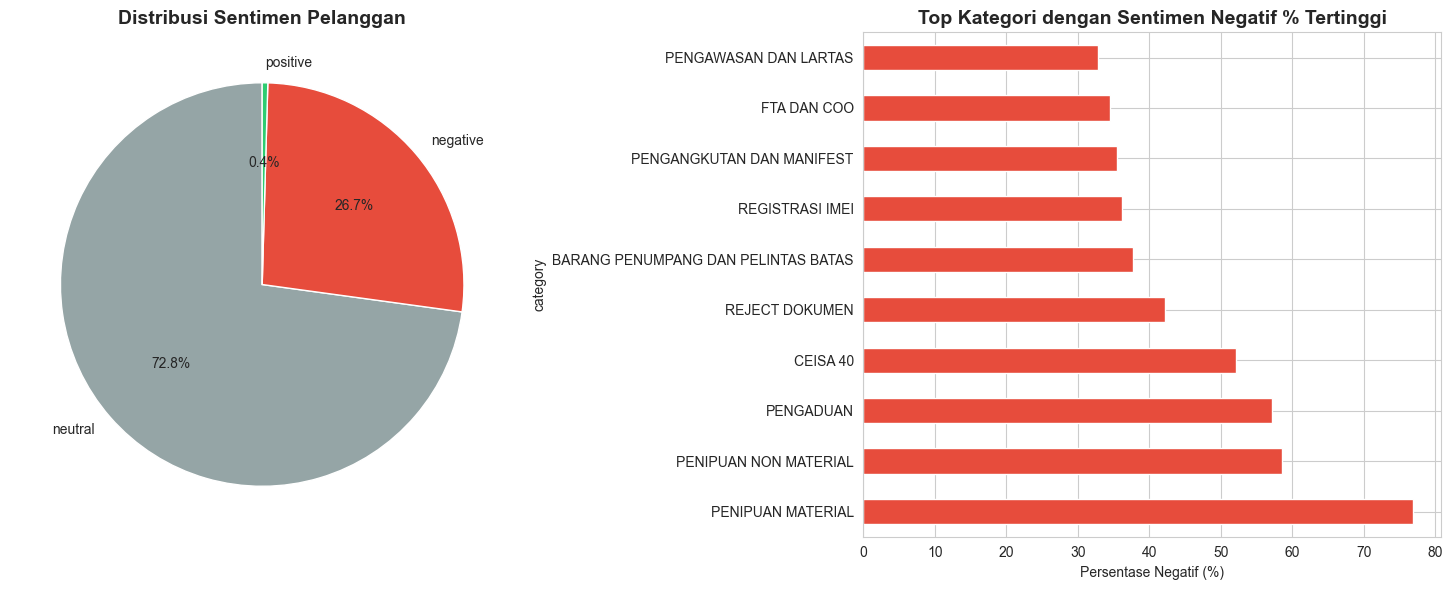


✅ Dashboard disimpan ke 'output/sentiment_dashboard.png'


In [16]:
from collections import Counter

# 1. Distribusi Persentase Sentimen
total = len(df_model)
counts = df_model['sentiment'].value_counts()
print("=== DISTRIBUSI SENTIMEN ===")
for label, val in counts.items():
    print(f"{label.upper():8}: {val:4} ({val/total*100:.1f}%)")

# 2. Kategori dengan Sentimen Negatif Tertinggi
if 'category' in df_model.columns:
    print("\n=== KATEGORI DENGAN PERSENTASE KELUHAN (NEGATIF) TERTINGGI ===")
    ct = pd.crosstab(df_model['category'], df_model['sentiment'], normalize='index') * 100
    # Filter kategori dengan jumlah minimal tiket agar tidak bias
    cat_counts = df_model['category'].value_counts()
    valid_cats = cat_counts[cat_counts >= 5].index
    ct_filtered = ct.loc[valid_cats]
    
    if 'negative' in ct_filtered.columns:
        top_neg_cats = ct_filtered.sort_values(by='negative', ascending=False).head(10)
        for idx, (cat, row) in enumerate(top_neg_cats.iterrows(), 1):
            print(f"{idx:2}. {cat[:40]:40} -> Negatif: {row['negative']:.1f}% (Total Tiket: {cat_counts[cat]})")

# 3. Kata Kunci Utama Keluhan (Sentimen Negatif)
neg_texts = df_model[df_model['sentiment'] == 'negative']['text_clean'].dropna().tolist()
if neg_texts:
    # Stopwords tambahan untuk visualisasi kata kunci agar lebih bersih
    custom_stopwords = {'yang', 'dan', 'di', 'ke', 'dari', 'pada', 'akan', 'untuk', 'dengan', 'saya', 'kami', 'ini', 'itu', 'atau', 'saja', 'sudah', 'belum', 'ada', 'tidak', 'bisa', 'pak', 'bu', 'min', 'kak', 'admin'}
    words = []
    for text in neg_texts:
        words.extend([w.lower() for w in text.split() if w.lower() not in custom_stopwords and len(w) > 3])
    
    word_counts = Counter(words)
    print("\n=== KATA KUNCI UTAMA PADA KELUHAN NEGATIF ===")
    for word, count in word_counts.most_common(10):
        print(f"- {word}: {count}x")

# 4. Visualisasi Dashboard
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie Chart Distribusi
colors = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=[colors.get(s, '#95a5a6') for s in counts.index], startangle=90)
axes[0].set_title('Distribusi Sentimen Pelanggan', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

# Bar Chart Kategori Negatif
if 'category' in df_model.columns and 'negative' in ct_filtered.columns:
    top_neg_cats['negative'].plot(kind='barh', ax=axes[1], color='#e74c3c')
    axes[1].set_title('Top Kategori dengan Sentimen Negatif % Tertinggi', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Persentase Negatif (%)')

plt.tight_layout()
plt.savefig('output/sentiment_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Dashboard disimpan ke 'output/sentiment_dashboard.png'")

# 6. DEPLOYMENT

### Rekomendasi Aksi Bisnis (Actionable Insights):
1. **Prioritas Perbaikan**: Fokuskan perbaikan kualitas pada kategori-kategori layanan yang memiliki sentimen negatif tertinggi berdasarkan hasil analisis evaluasi.
2. **Penanganan Kata Kunci Keluhan**: Segera lakukan standardisasi manual/FAQ atau optimasi sistem penanganan untuk kata-kata kunci keluhan (seperti 'gagal', 'error', 'pending', atau 'reject') agar waktu tunggu pelayanan berkurang.
3. **Integrasi Dashboard**: Dashboard visualisasi (`output/sentiment_dashboard.png`) dan hasil data sentimen (`output/sentiment_results.csv`) dapat diekspor secara mingguan atau dikirimkan ke pihak manajemen subdirektorat MONEV sebagai basis pengambilan keputusan kebijakan layanan.